In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
df = pd.read_csv("creditcard.csv")

print(df.head())

print(df.shape)

   Time        V1        V2        V3        V4        V5        V6        V7  \
0     0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1     0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2     1 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3     1 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4     2 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [3]:
print(df.isnull().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       1
V11       1
V12       1
V13       1
V14       1
V15       1
V16       1
V17       1
V18       1
V19       1
V20       1
V21       1
V22       1
V23       1
V24       1
V25       1
V26       1
V27       1
V28       1
Amount    1
Class     1
dtype: int64


In [4]:
df = df.dropna()

In [5]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
Index: 63471 entries, 0 to 63470
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    63471 non-null  int64  
 1   V1      63471 non-null  float64
 2   V2      63471 non-null  float64
 3   V3      63471 non-null  float64
 4   V4      63471 non-null  float64
 5   V5      63471 non-null  float64
 6   V6      63471 non-null  float64
 7   V7      63471 non-null  float64
 8   V8      63471 non-null  float64
 9   V9      63471 non-null  float64
 10  V10     63471 non-null  float64
 11  V11     63471 non-null  float64
 12  V12     63471 non-null  float64
 13  V13     63471 non-null  float64
 14  V14     63471 non-null  float64
 15  V15     63471 non-null  float64
 16  V16     63471 non-null  float64
 17  V17     63471 non-null  float64
 18  V18     63471 non-null  float64
 19  V19     63471 non-null  float64
 20  V20     63471 non-null  float64
 21  V21     63471 non-null  float64
 22  V22

Class
0.0    63306
1.0      165
Name: count, dtype: int64


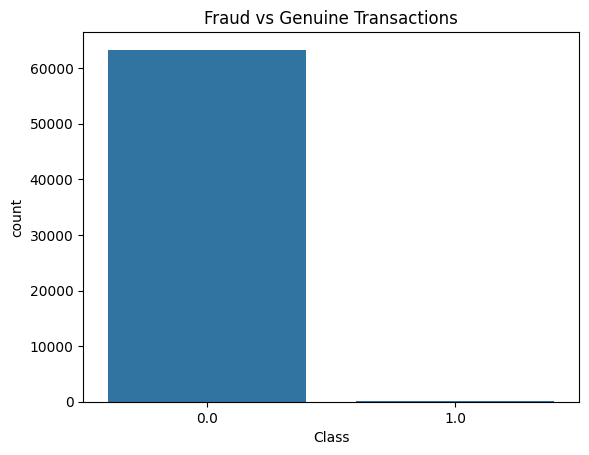

In [6]:
print(df['Class'].value_counts())

sns.countplot(x='Class', data=df)
plt.title("Fraud vs Genuine Transactions")
plt.show()

In [8]:
scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df[['Amount']])
df['Time'] = scaler.fit_transform(df[['Time']])

In [9]:
X = df.drop("Class", axis=1)
y = df["Class"]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [11]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

Accuracy: 0.9990547459629775
[[12657     5]
 [    7    26]]


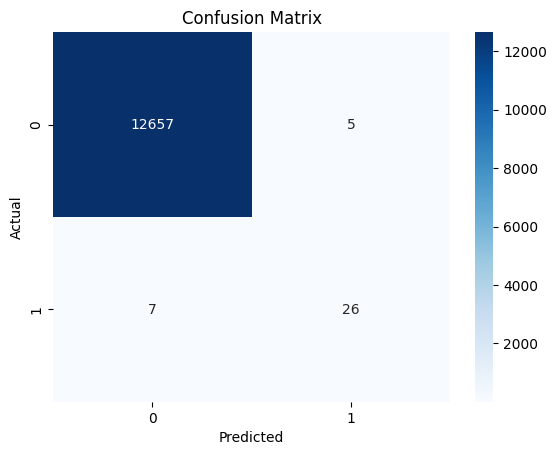

In [12]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
cm = confusion_matrix(y_test, y_pred)
print(cm)
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [13]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     12662
         1.0       0.84      0.79      0.81        33

    accuracy                           1.00     12695
   macro avg       0.92      0.89      0.91     12695
weighted avg       1.00      1.00      1.00     12695



In [14]:
importance = model.feature_importances_
features = X.columns
imp = pd.DataFrame({
    'Feature': features,
    'Importance': importance
})

imp = imp.sort_values(by='Importance', ascending=False)

print(imp.head(10))

   Feature  Importance
17     V17    0.146779
14     V14    0.136776
12     V12    0.117992
9       V9    0.095048
10     V10    0.063528
11     V11    0.063333
16     V16    0.055205
4       V4    0.038181
18     V18    0.035033
26     V26    0.034437


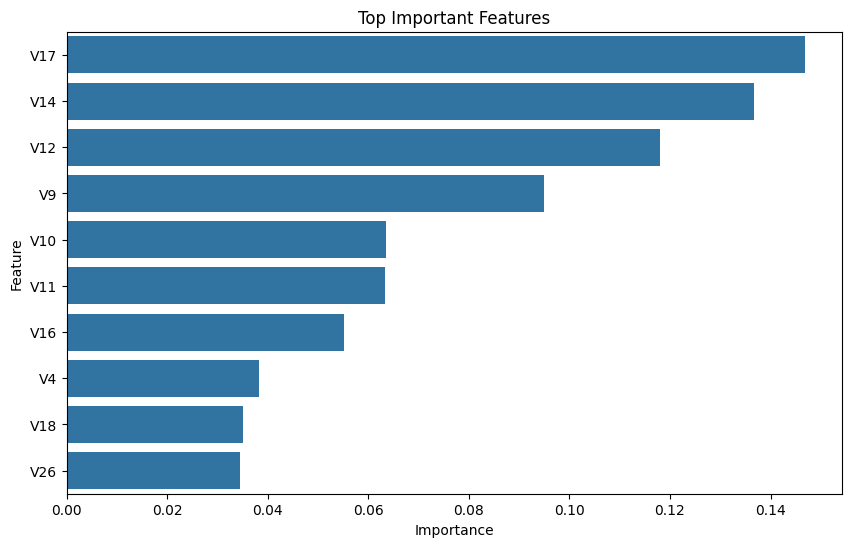

In [15]:
plt.figure(figsize=(10,6))
sns.barplot(x='Importance',
            y='Feature',
            data=imp.head(10))

plt.title("Top Important Features")

plt.show()

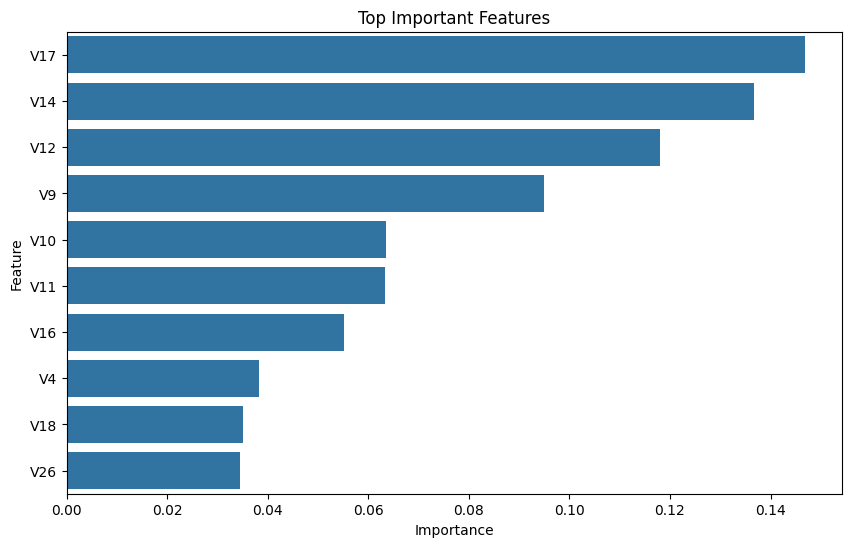

In [16]:
plt.figure(figsize=(10,6))
sns.barplot(x='Importance',
            y='Feature',
            data=imp.head(10))

plt.title("Top Important Features")

plt.show()